In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers


C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
train_dir = r"E:\Pyhton code\Data Sets\archive\skin_diseases\SkinDisease\SkinDisease\train"
test_dir = r"E:\Pyhton code\Data Sets\archive\skin_diseases\SkinDisease\SkinDisease\test"

In [3]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True,
    fill_mode='nearest'
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32, # Increased batch size for smoother gradients
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)


Found 5592 images belonging to 8 classes.
Found 618 images belonging to 8 classes.


In [4]:
#check data
print(train_data.class_indices)
print(train_data.num_classes)

{'Acne': 0, 'Benign_tumors': 1, 'DrugEruption': 2, 'Eczema': 3, 'Infestations_Bites': 4, 'Psoriasis': 5, 'SkinCancer': 6, 'Sun_Sunlight_Damage': 7}
8


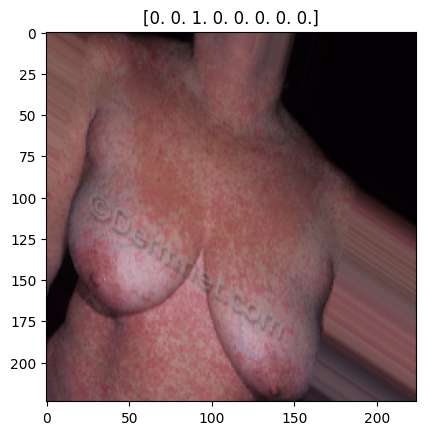

In [5]:
images, labels = next(train_data)
plt.imshow(images[0])
plt.title(labels[0])
plt.show()

In [6]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False   # Stage 1: completely freeze base model

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.4),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,096 (9.89 MB)

 Trainable params: 332,552 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [7]:
# Model Compilation for Stage 1 completed above.


In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


In [9]:
print("Starting Stage 1: Training Custom Head...")
history_stage1 = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)


Starting Stage 1: Training Custom Head...
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.3938 - loss: 5.1827 - val_accuracy: 0.5032 - val_loss: 3.8129 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.4816 - loss: 3.3251 - val_accuracy: 0.5162 - val_loss: 2.7248 - learning_rate: 0.0010
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.5156 - loss: 2.4239 - val_accuracy: 0.5388 - val_loss: 2.1627 - learning_rate: 0.0010
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - accuracy: 0.5381 - loss: 1.9932 - val_accuracy: 0.5599 - val_loss: 1.8961 - learning_rate: 0.0010
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.5236 - loss: 1.8338 - val_accuracy: 0.5275 - val_loss: 1.7922 - learning_rate: 0.0010
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 241s 1s/step - accuracy: 0.5302 - loss: 1.7591 - val_accuracy: 0.5728 - val_loss: 1.6880 - learning_rate: 0.0010
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 

In [10]:
print("Starting Stage 2: Deep Fine-Tuning MobileNetV2...")
base_model.trainable = True

# Refreeze the first 100 layers (low-level features)
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with micro learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_stage2 = model.fit(
    train_data,
    validation_data=test_data,
    epochs=25,
    callbacks=[early_stop, reduce_lr]
)


Starting Stage 2: Deep Fine-Tuning MobileNetV2...
Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.4460 - loss: 1.9397 - val_accuracy: 0.4887 - val_loss: 1.9405 - learning_rate: 1.0000e-05
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.4950 - loss: 1.7933 - val_accuracy: 0.4935 - val_loss: 2.0017 - learning_rate: 1.0000e-05
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 319s 2s/step - accuracy: 0.5256 - loss: 1.7442 - val_accuracy: 0.4660 - val_loss: 2.0027 - learning_rate: 1.0000e-05
Epoch 4/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.5336 - loss: 1.6928 - val_accuracy: 0.4854 - val_loss: 1.9342 - learning_rate: 5.0000e-06
Epoch 5/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.5406 - loss: 1.6662 - val_accuracy: 0.5000 - val_loss: 1.8668 - learning_rate: 5.0000e-06


In [11]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 617ms/step - accuracy: 0.4887 - loss: 1.9405
Test Accuracy: 0.4886731505393982


In [12]:
model.save("skin_model.h5")

In [13]:
from tensorflow.keras.preprocessing import image

img_path = r"E:\Pyhton code\Data Sets\archive\skin_diseases\SkinDisease\SkinDisease\test\Acne\157__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg"   # change this

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

pred = model.predict(img_array)

class_names = list(train_data.class_indices.keys())

print("Prediction:", class_names[np.argmax(pred)])
print("Confidence:", float(np.max(pred)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Acne
Confidence: 0.8951905965805054


In [14]:
import pickle

class_names = list(train_data.class_indices.keys())

pickle.dump(class_names, open("class_names.pkl", "wb"))

In [15]:
# from google.colab import files

# files.download("skin_model.h5")
# files.download("class_names.pkl")